In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
from numpy._core.defchararray import upper
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import pickle
import sklearn
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.feature_selection import f_classif, SelectKBest
import numpy as np
from sklearn.model_selection import RandomizedSearchCV
import warnings
from sklearn.feature_selection import SelectKBest

def warn(*args, **kwargs):
    pass
import math
warnings.warn = warn

## **Paso 1: Buscar un conjunto de datos**

**Descripción**

Este conjunto de datos simula un entorno académico realista para **10,000 estudiantes** y está diseñado para predecir la **deserción estudiantil**. Incluye variables demográficas, de comportamiento y de rendimiento académico, como **GPA, GPA del semestre, CGPA, hábitos de estudio, asistencia, índice de estrés, educación de los padres y departamento académico**.

Aunque es un conjunto de datos sintético, los datos imitan de cerca distribuciones reales de estudiantes, incluyendo **ligera asimetría (skewness) en los ingresos y el estrés**, **valores faltantes (~5%) en algunas variables**, y **correlaciones lógicas entre el rendimiento académico y el riesgo de deserción**.

**Variable objetivo:**

Dropout (0 = continúa estudiando, 1 = abandona)

**Características principales:**

- **Student_ID:** Identificador único del estudiante  
- **Age:** Edad del estudiante en años  
- **Gender:** Masculino / Femenino  
- **Family_Income:** Ingreso familiar mensual  
- **Internet_Access:** Sí / No  
- **Study_Hours_per_Day:** Promedio de horas de estudio por día  
- **Attendance_Rate:** Porcentaje de asistencia  
- **Assignment_Delay_Days:** Promedio de días de retraso en la entrega de tareas  
- **Travel_Time_Minutes:** Tiempo diario de desplazamiento en minutos  
- **Part_Time_Job:** Sí / No  
- **Scholarship:** Sí / No  
- **Stress_Index:** Nivel de estrés reportado por el estudiante (1–10)  
- **GPA, Semester_GPA, CGPA:** Rendimiento académico  
- **Semester:** Año actual (Año 1–4)  
- **Department:** Science, Arts, Business, CS, Engineering  
- **Parental_Education:** Nivel educativo más alto de los padres  

**Características del dataset:**

- **Filas:** 10,000  
- **Columnas:** 19  
- **Tasa de deserción:** 23.5%  

Contiene **variables categóricas y numéricas**.  
Hay **valores faltantes en aproximadamente el 5–5.1% de algunas columnas** (algo realista en datasets educativos).

In [2]:
total_data = pd.read_csv("/workspaces/machine-learning-python-template10-JohnnyXavierReyesBorbor/data/raw/student_dropout_dataset_v3.csv")
total_data


,Student_ID,Age,Gender,Family_Income,Internet_Access,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Part_Time_Job,Scholarship,Stress_Index,GPA,Semester_GPA,CGPA,Semester,Department,Parental_Education,Dropout
0,1,22.1,Male,25000.0,Yes,3.36,86.1,2,20.4,Yes,No,5.5,0.96,0.90,0.90,Year 1,Arts,High School,0
1,2,20.7,Male,25000.0,Yes,4.30,68.0,2,44.0,No,No,6.8,1.28,1.20,1.19,Year 3,Engineering,Bachelor,1
2,3,22.4,Male,40183.0,Yes,4.40,70.9,0,48.9,Yes,No,5.5,1.68,1.32,1.32,Year 1,Arts,Master,0
3,4,24.4,Male,NaN,Yes,NaN,82.2,2,38.6,No,No,NaN,1.78,1.77,1.77,Year 1,CS,High School,1
4,5,20.5,Female,25319.0,Yes,4.19,75.7,1,23.0,No,No,7.0,1.48,0.91,0.87,Year 4,Business,Bachelor,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,23.9,Female,42286.0,No,4.62,92.0,0,10.0,Yes,Yes,5.5,1.60,0.99,0.97,Year 2,Arts,Bachelor,0
9996,9997,17.0,Female,61103.0,Yes,2.87,75.2,3,32.4,No,Yes,6.7,3.09,3.09,3.09,Year 1,Business,Master,1
9997,9998,19.4,Male,25000.0,Yes,4.73,74.9,4,25.4,No,No,3.5,3.45,3.37,3.43,Year 4,Business,Bachelor,0
9998,9999,22.1,Female,40302.0,Yes,5.85,74.2,1,5.0,No,Yes,6.2,3.35,3.34,3.34,Year 1,CS,High School,0


## **Paso 2: Desarrolla un modelo**
Una vez hayas encontrado tu conjunto de datos ideal, analízalo y entrena un modelo. Optimízalo si fuera necesario.

In [3]:
#Conocer las dimensiones
total_data.shape
print(f"Hay {total_data.shape[0]} filas y {total_data.shape[1]} columnas")

Hay 10000 filas y 19 columnas


In [4]:
# Obtener información sobre tipos de datos y valores no nulos
total_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Student_ID             10000 non-null  int64  
 1   Age                    10000 non-null  float64
 2   Gender                 10000 non-null  str    
 3   Family_Income          9500 non-null   float64
 4   Internet_Access        10000 non-null  str    
 5   Study_Hours_per_Day    9500 non-null   float64
 6   Attendance_Rate        10000 non-null  float64
 7   Assignment_Delay_Days  10000 non-null  int64  
 8   Travel_Time_Minutes    10000 non-null  float64
 9   Part_Time_Job          10000 non-null  str    
 10  Scholarship            10000 non-null  str    
 11  Stress_Index           9500 non-null   float64
 12  GPA                    10000 non-null  float64
 13  Semester_GPA           10000 non-null  float64
 14  CGPA                   10000 non-null  float64
 15  Semester      

Hay 500 nulos en algunas de las variables

In [5]:
total_data.dropna(inplace=True)
total_data.info()

<class 'pandas.DataFrame'>
Index: 9020 entries, 0 to 9999
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Student_ID             9020 non-null   int64  
 1   Age                    9020 non-null   float64
 2   Gender                 9020 non-null   str    
 3   Family_Income          9020 non-null   float64
 4   Internet_Access        9020 non-null   str    
 5   Study_Hours_per_Day    9020 non-null   float64
 6   Attendance_Rate        9020 non-null   float64
 7   Assignment_Delay_Days  9020 non-null   int64  
 8   Travel_Time_Minutes    9020 non-null   float64
 9   Part_Time_Job          9020 non-null   str    
 10  Scholarship            9020 non-null   str    
 11  Stress_Index           9020 non-null   float64
 12  GPA                    9020 non-null   float64
 13  Semester_GPA           9020 non-null   float64
 14  CGPA                   9020 non-null   float64
 15  Semester            

In [6]:
total_data.drop(columns=["Student_ID"], inplace=True)

# Elimino 2 de las métricas  relacionadas a las notas.
total_data.drop(columns=["Semester_GPA","CGPA"], inplace=True)

In [7]:
vars_numericas = total_data.select_dtypes(include=["int64", "float64"]).columns.tolist()
vars_categoricas = total_data.select_dtypes(include=["object"]).columns.tolist()
target="Dropout"
print(vars_categoricas,vars_numericas)

['Gender', 'Internet_Access', 'Part_Time_Job', 'Scholarship', 'Semester', 'Department', 'Parental_Education'] ['Age', 'Family_Income', 'Study_Hours_per_Day', 'Attendance_Rate', 'Assignment_Delay_Days', 'Travel_Time_Minutes', 'Stress_Index', 'GPA', 'Dropout']


In [8]:
num_duplicates = total_data.duplicated().sum()
print(f"Número de filas duplicadas: {num_duplicates}")

if num_duplicates > 0:
    total_data = total_data.drop_duplicates().reset_index(drop = True)
    print(f"Número duplicados borrados. Ahora hay {total_data.shape[0]} datos")
else:
    print("No se han encontrado duplicados")

Número de filas duplicadas: 0
No se han encontrado duplicados


## **Análisis de Variables Categóricas**

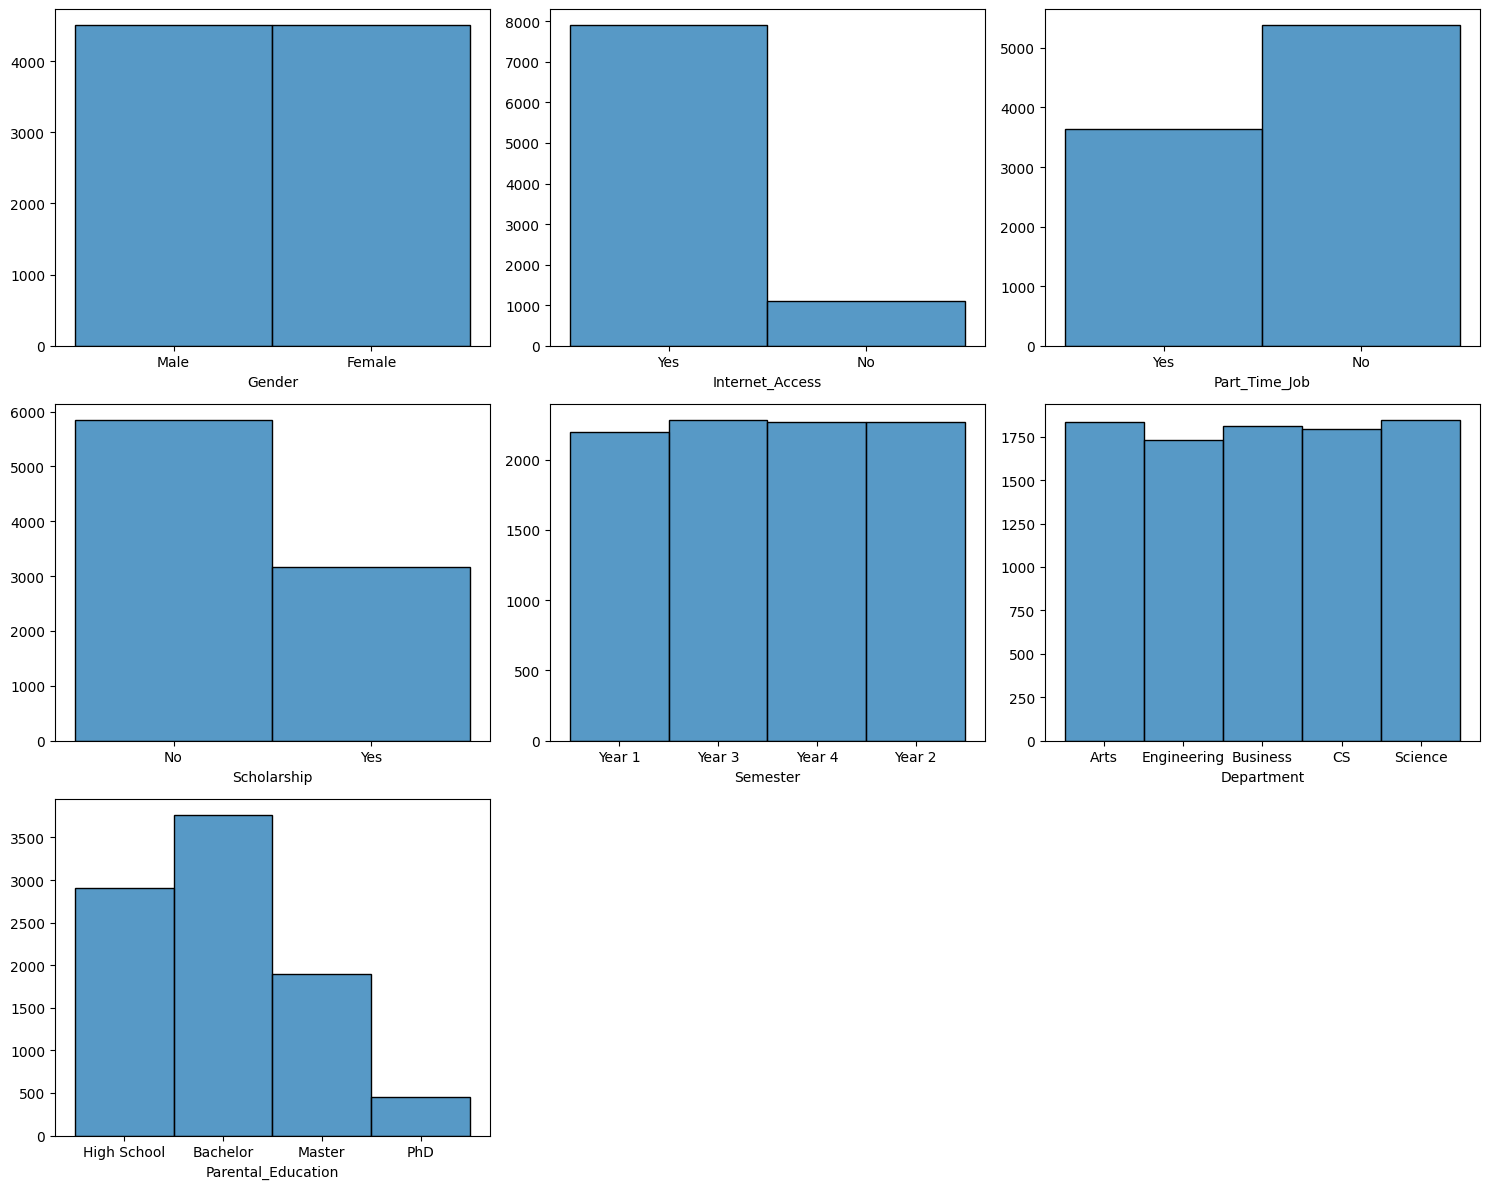

In [9]:
n_cols = 3
n_rows = math.ceil(len(vars_categoricas) / n_cols)
fig, axis = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))

axis = axis.flatten()   

for i, col in enumerate(vars_categoricas):
    sns.histplot(ax=axis[i], data=total_data, x=col).set_ylabel(None)

for j in range(len(vars_categoricas), len(axis)):
    fig.delaxes(axis[j])

plt.tight_layout()
plt.show()

### **Conclusiones del Análisis de Variables Categóricas**

- La distribución de **género** en el dataset es bastante equilibrada.

- En cuanto al **acceso a internet**, la gran mayoría de los estudiantes tienen wifi. Esto podría indicar que la falta de acceso a internet es un factor potencial de riesgo académico.

- Respecto al **trabajo a tiempo parcial**, una mayor cantidad de estudiantes no tiene empleo mientras estudia. Esto podría influir en el tiempo disponible para estudiar y, potencialmente, en el rendimiento académico.

- La variable **beca** muestra que la mayoría de los estudiantes no reciben beca, mientras que una pequeña parte sí cuentan con beca.

## **Análisis de Variables Numéricas**

Las variables numéricas son ['Age', 'Family_Income', 'Study_Hours_per_Day', 'Attendance_Rate', 'Assignment_Delay_Days', 'Travel_Time_Minutes', 'Stress_Index', 'GPA', 'Dropout']


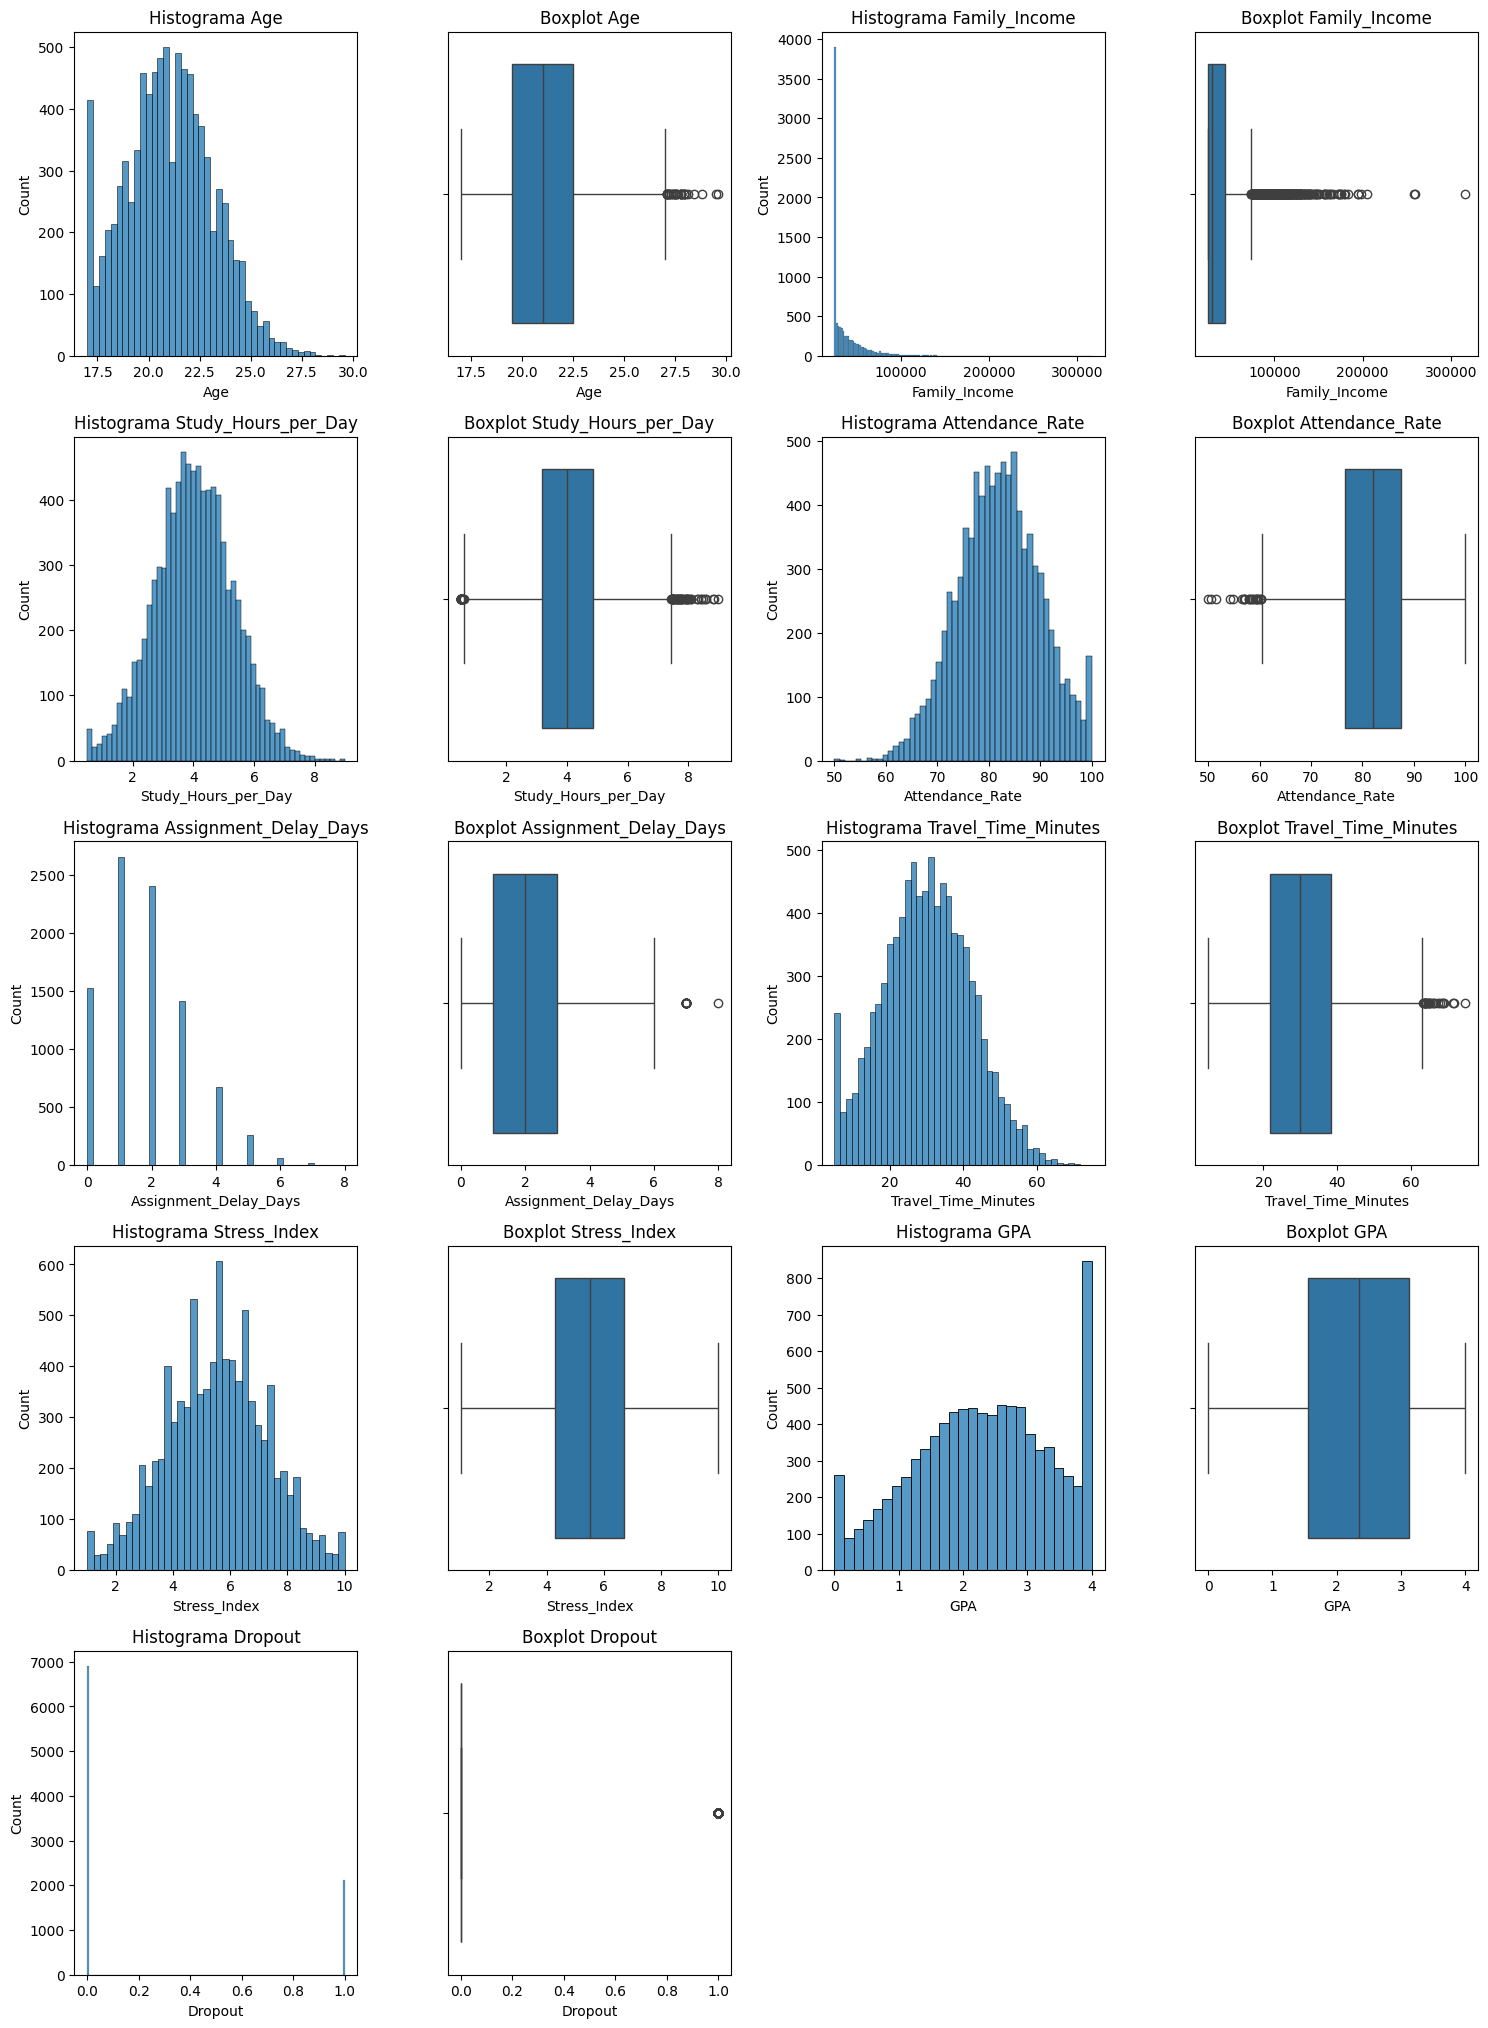

In [10]:
print(f"Las variables numéricas son {vars_numericas}")

n_cols = 4
n_rows = 2*(math.ceil(len(vars_numericas) / n_cols))

fig, axis = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axis = axis.flatten()

for i, col in enumerate(vars_numericas):
    sns.histplot(data=total_data, x=col, ax=axis[2*i])
    axis[2*i].set_title(f"Histograma {col}")

    sns.boxplot(data=total_data, x=col, ax=axis[2*i + 1])
    axis[2*i + 1].set_title(f"Boxplot {col}")

# Eliminar subplots sobrantes
for j in range(2*i + 2, len(axis)):
    fig.delaxes(axis[j])

plt.tight_layout()
plt.show()

### **Conclusiones del Análisis de Variables Numéricas**

- La variable **Age** presenta una distribución aproximadamente normal centrada alrededor de los 20–22 años. Se observan algunos valores atípicos en edades mayores.

- **Family_Income:** La mayoría de los estudiantes proviene de hogares con ingresos relativamente bajos o medios, mientras que unos pocos casos presentan ingresos muy altos, lo que genera varios outliers.

- La variable **Study_Hours_per_Day** sigue una distribución cercana a la normal, concentrándose alrededor de 4–5 horas de estudio diarias. 

- **Attendance_Rate** presenta una distribución centrada en valores altos (alrededor de 80–90%), lo cual indica que la mayoría de los estudiantes mantiene niveles de asistencia elevados. Sin embargo, existen algunos valores atípicos.

- En **Assignment_Delay_Days**, la mayor parte de los estudiantes entrega las tareas con pocos días de retraso, generalmente entre 0 y 3 días. Aun así, hay ciertos outliers.

- **Travel_Time_Minutes** muestra una distribución aproximadamente normal centrada entre 20 y 30 minutos.

- La variable **Stress_Index** presenta una distribución  aproximadamente normal.

- En **GPA**, la mayoría de los estudiantes se concentra entre valores medios y altos

## **Análisis vs Target**

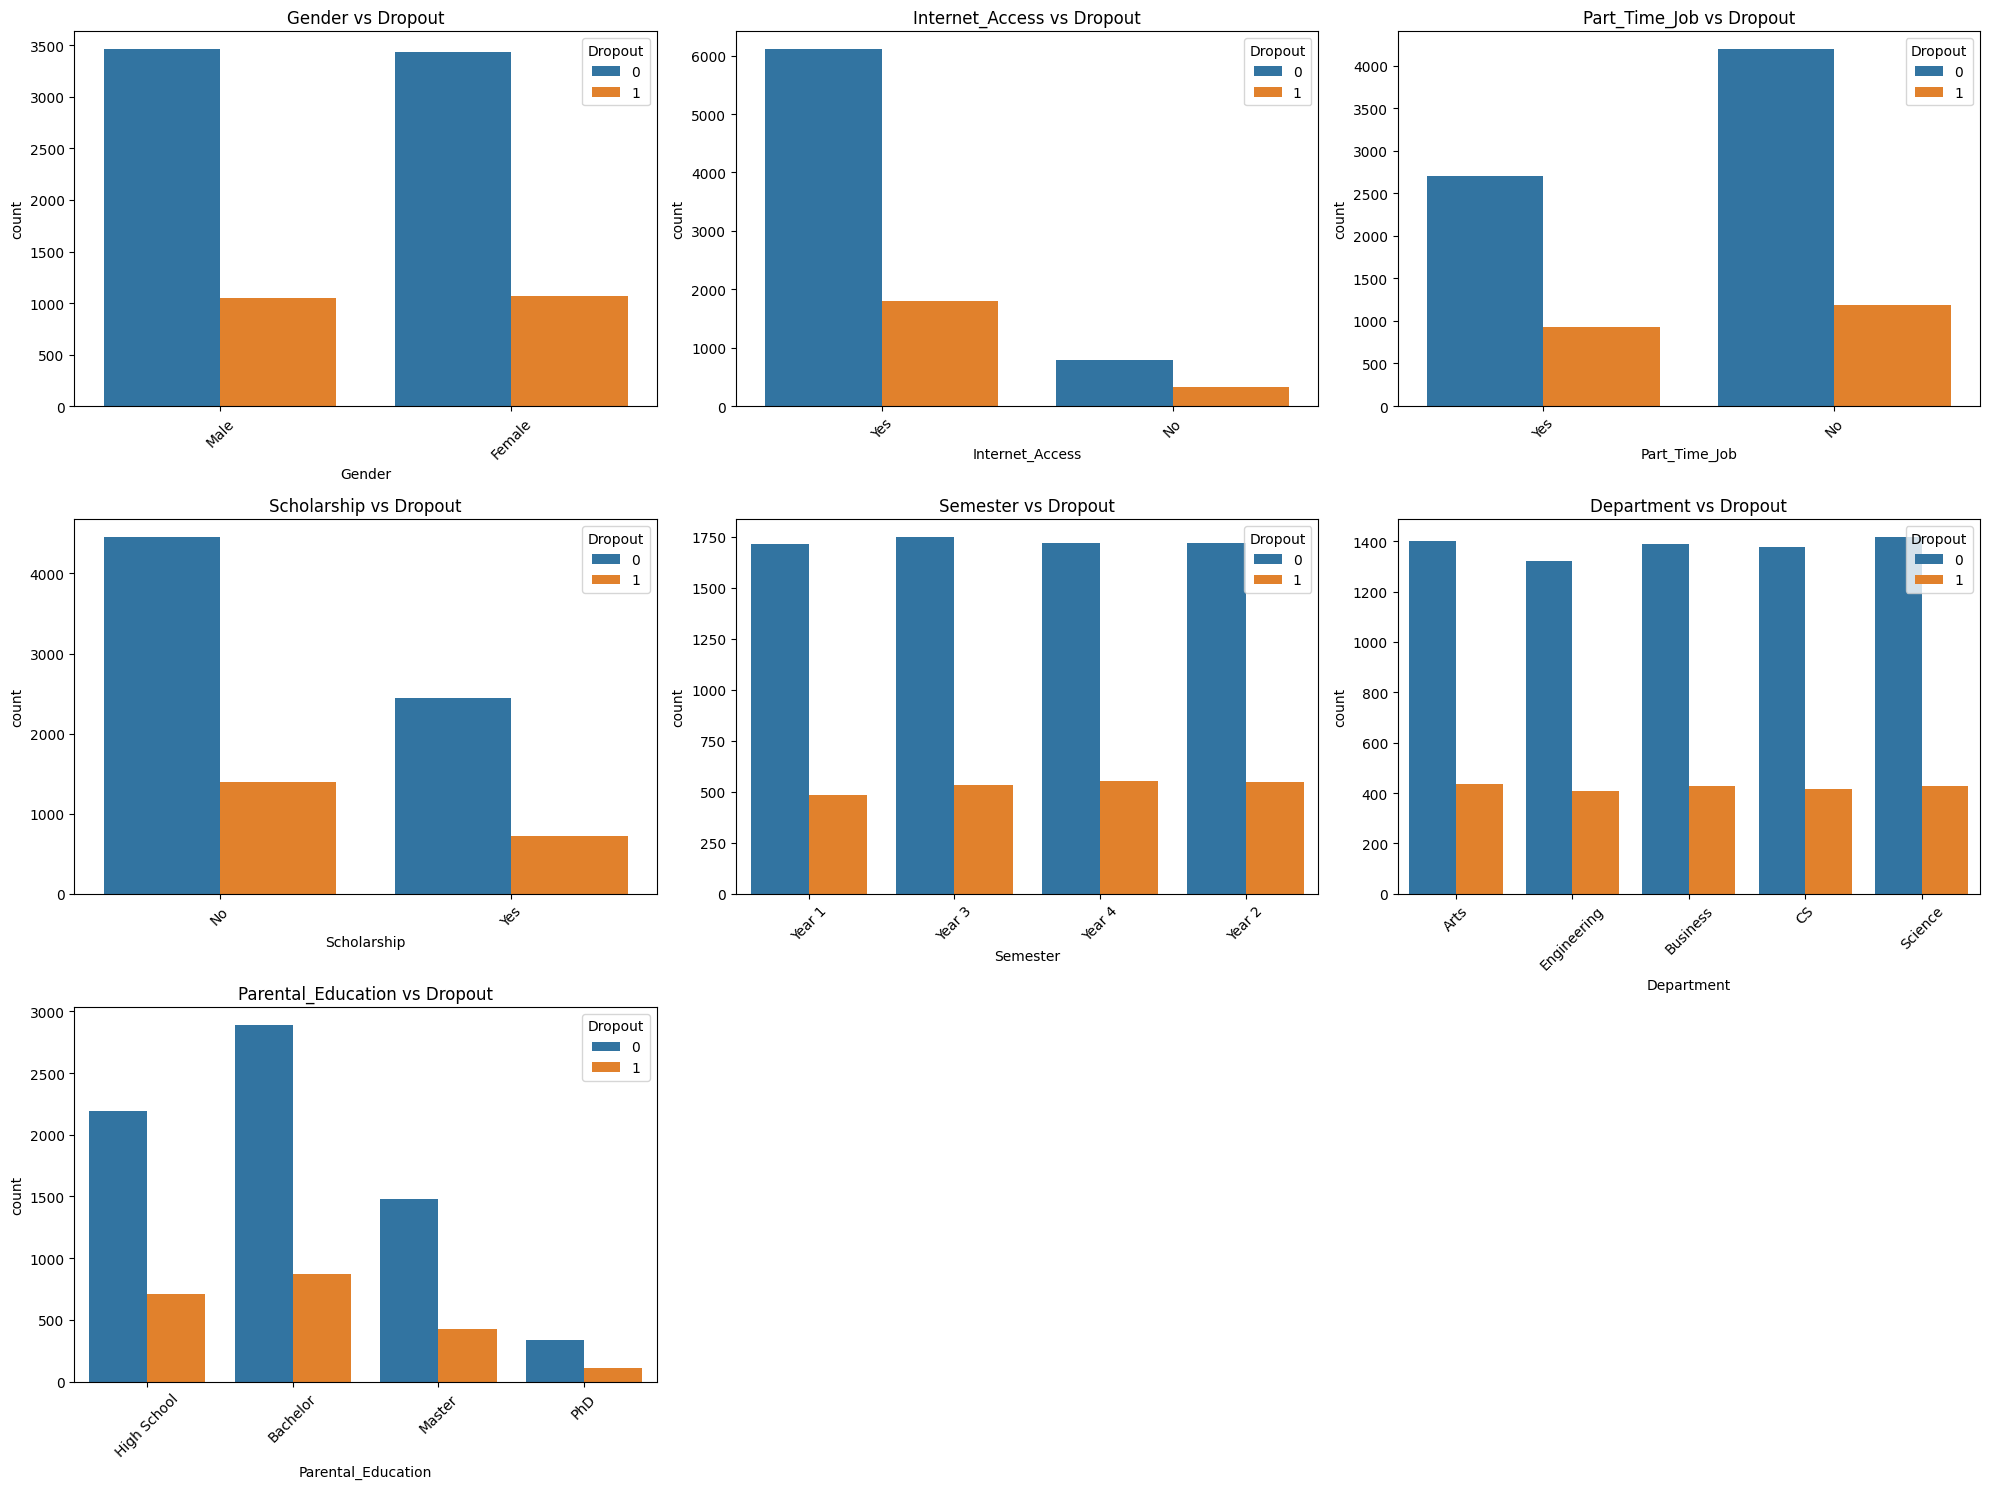

In [11]:
n_cols = 3
n_rows = math.ceil(len(vars_categoricas) / n_cols)

fig, axis = plt.subplots(n_rows, n_cols, figsize=(20, 5 * n_rows))

axis = np.array(axis).flatten()  

for i, col in enumerate(vars_categoricas):
    sns.countplot(
        ax=axis[i],
        data=total_data,
        x=col,
        hue=target
    )
    axis[i].set_title(f"{col} vs {target}")
    axis[i].tick_params(axis='x', rotation=45)

# Eliminar ejes vacíos si sobran
for j in range(len(vars_categoricas), len(axis)):
    fig.delaxes(axis[j])

plt.tight_layout()
plt.show()

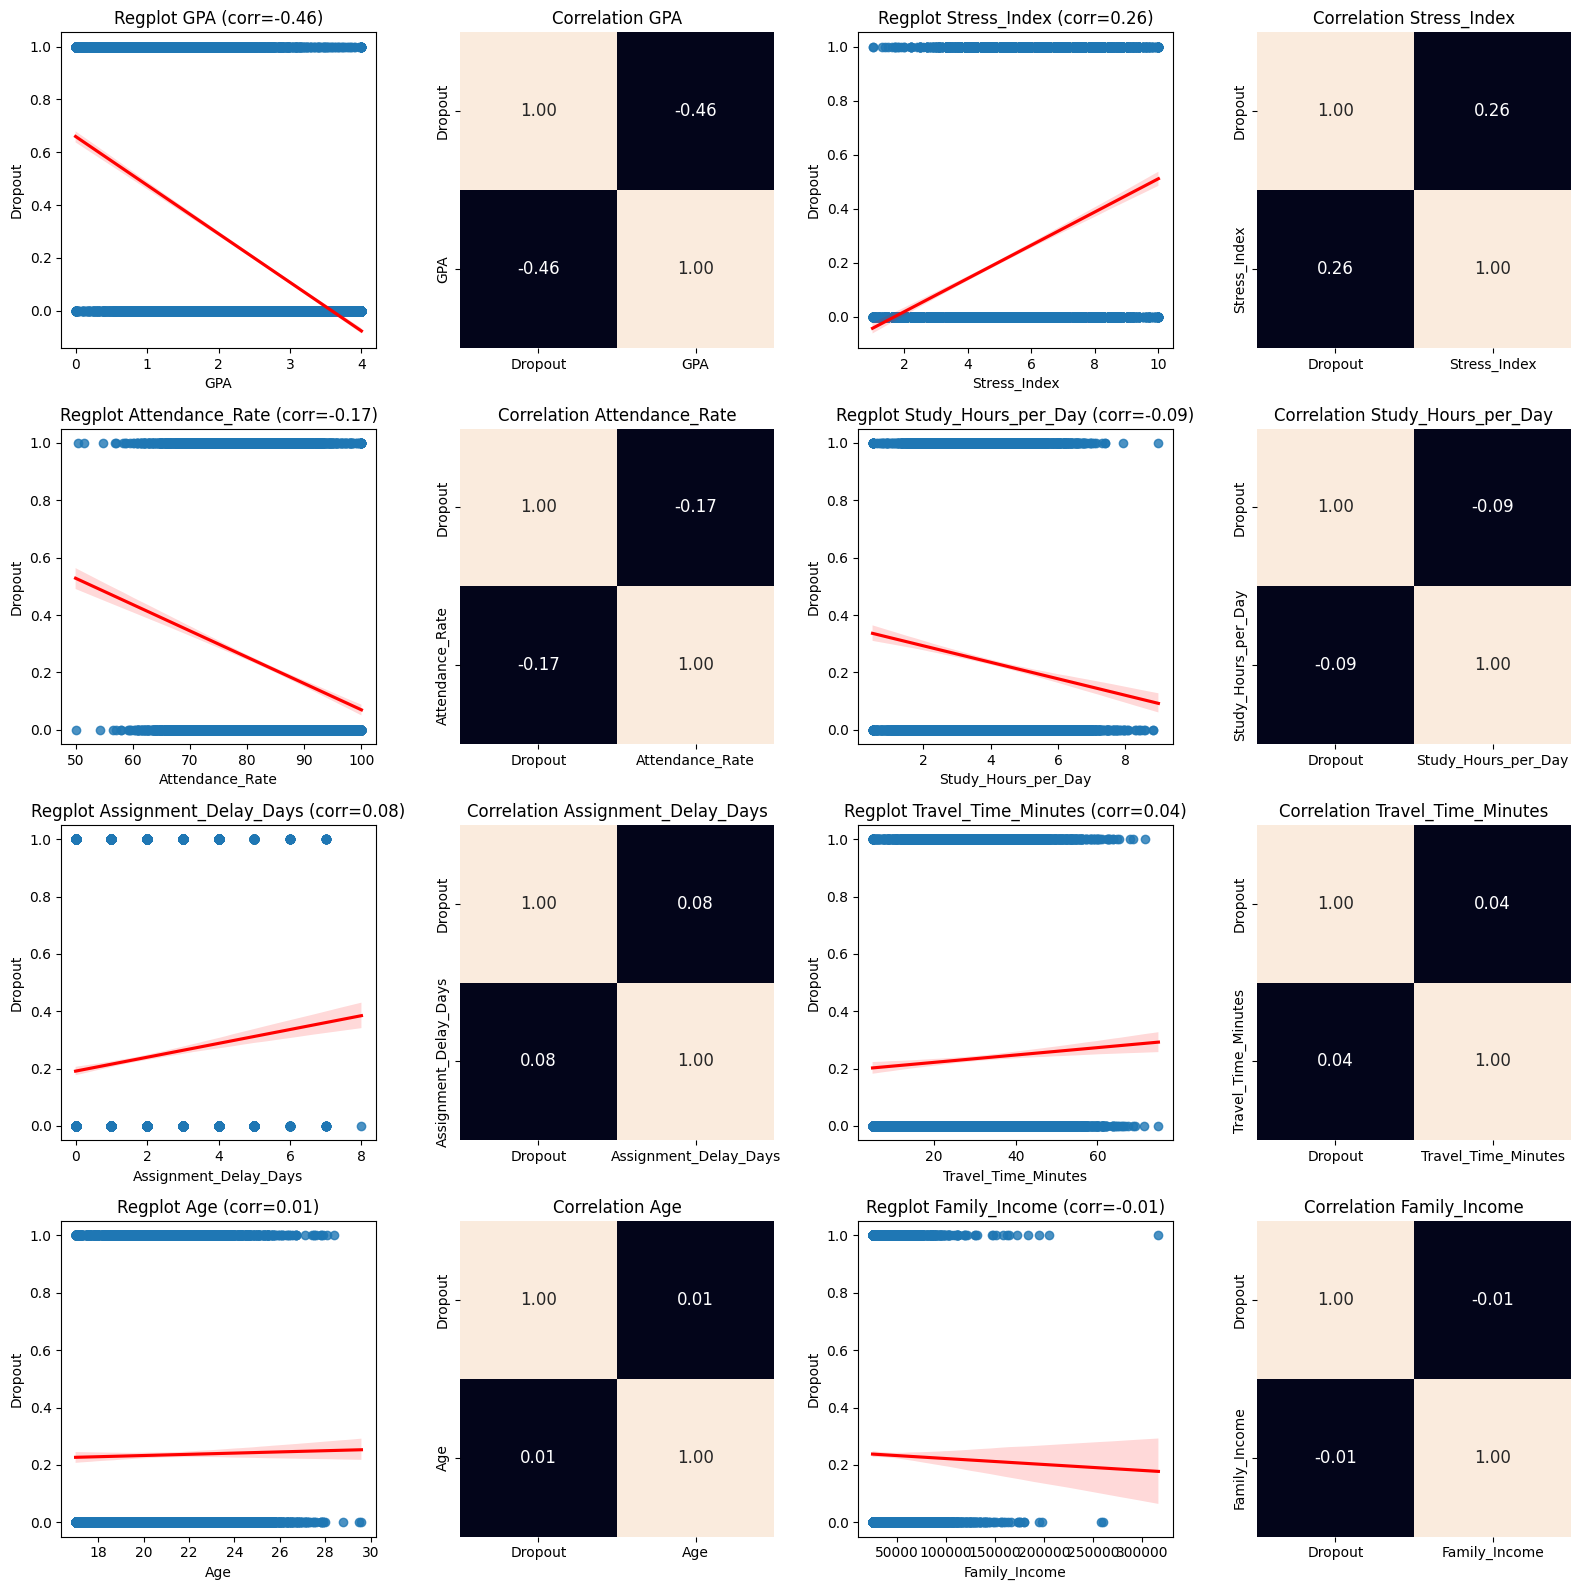

In [12]:
n_cols = 4
target = "Dropout"
vars_num_sin_pred = [col for col in vars_numericas if col != target]

# Calcular correlaciones y ordenar por valor absoluto
corr_values = total_data[vars_num_sin_pred + [target]].corr()[target].drop(target)
corr_values = corr_values.reindex(corr_values.abs().sort_values(ascending=False).index)

vars_ordenadas = corr_values.index.tolist()

n_rows = 2 * (math.ceil(len(vars_ordenadas) / n_cols))

fig, axis = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
axis = axis.flatten()

for i, col in enumerate(vars_ordenadas):
    
    # Regplot
    sns.regplot(
        ax=axis[2*i],
        data=total_data,
        x=col,
        y=target,
        line_kws={"color": "red"}
    )
    
    axis[2*i].set_title(f"Regplot {col} (corr={corr_values[col]:.2f})", fontsize=12)
    axis[2*i].tick_params(labelsize=10)

    # Heatmap
    sns.heatmap(
        total_data[[target, col]].corr(),
        annot=True,
        fmt=".2f",
        ax=axis[2*i + 1],
        cbar=False,
        annot_kws={"size": 12}
    )

    axis[2*i + 1].set_title(f"Correlation {col}", fontsize=12)

# Eliminar subplots sobrantes
for j in range(2*i + 2, len(axis)):
    fig.delaxes(axis[j])

plt.tight_layout()
plt.show()

In [13]:
vars_categoricas_n = []

for col in vars_categoricas:
    
    total_data[f"{col}_n"] = pd.factorize(total_data[col])[0]
    
    transformation_rules = dict(
        total_data[[col, f"{col}_n"]]
        .drop_duplicates()
        .values
    )
    
    with open(f"./{col}_transformation_rules.json", "w") as f:
        json.dump(transformation_rules, f)
    
    vars_categoricas_n.append(f"{col}_n")  
variables=vars_numericas+vars_categoricas_n
total_data=total_data[variables]

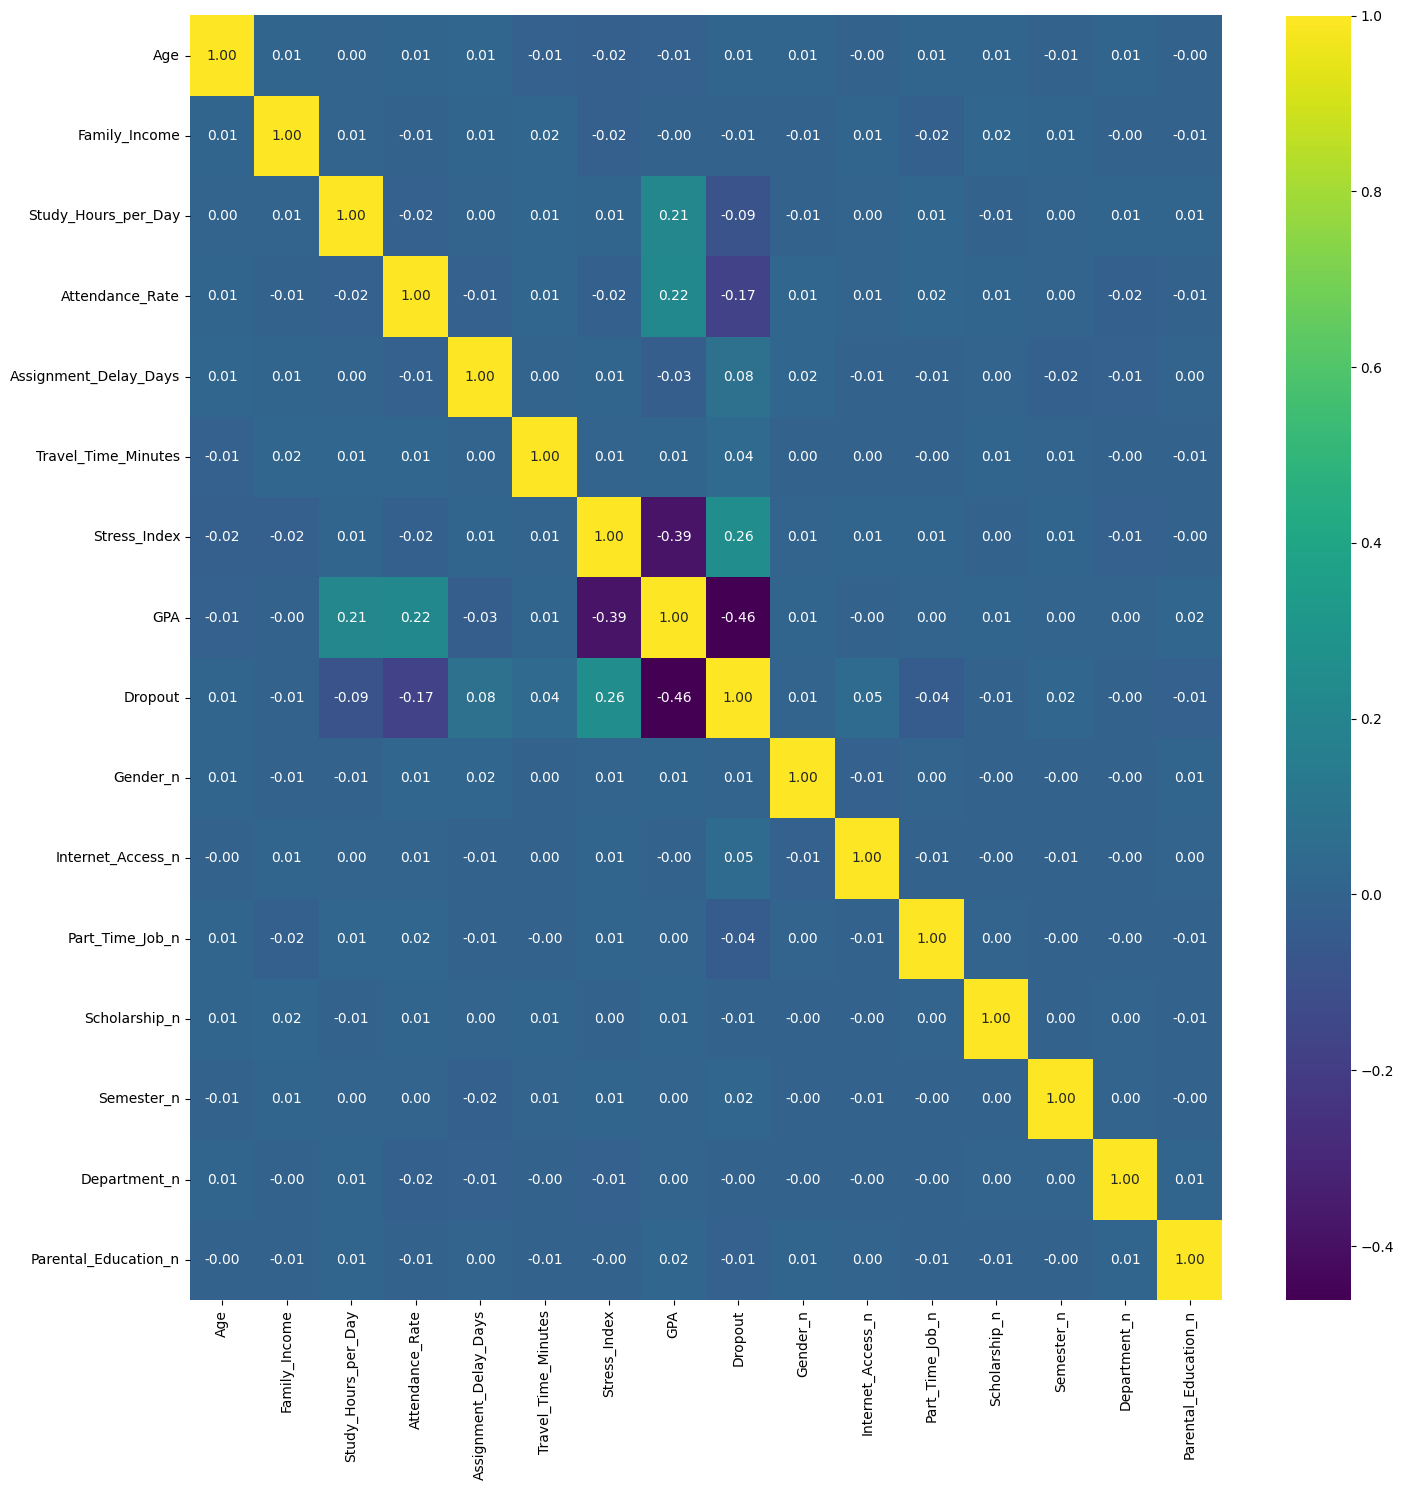

In [14]:
fig, ax = plt.subplots(figsize=(15,15))
sns.heatmap(total_data.corr(method="pearson"), annot=True, fmt=".2f", cmap="viridis", ax=ax)
plt.tight_layout()
plt.show()

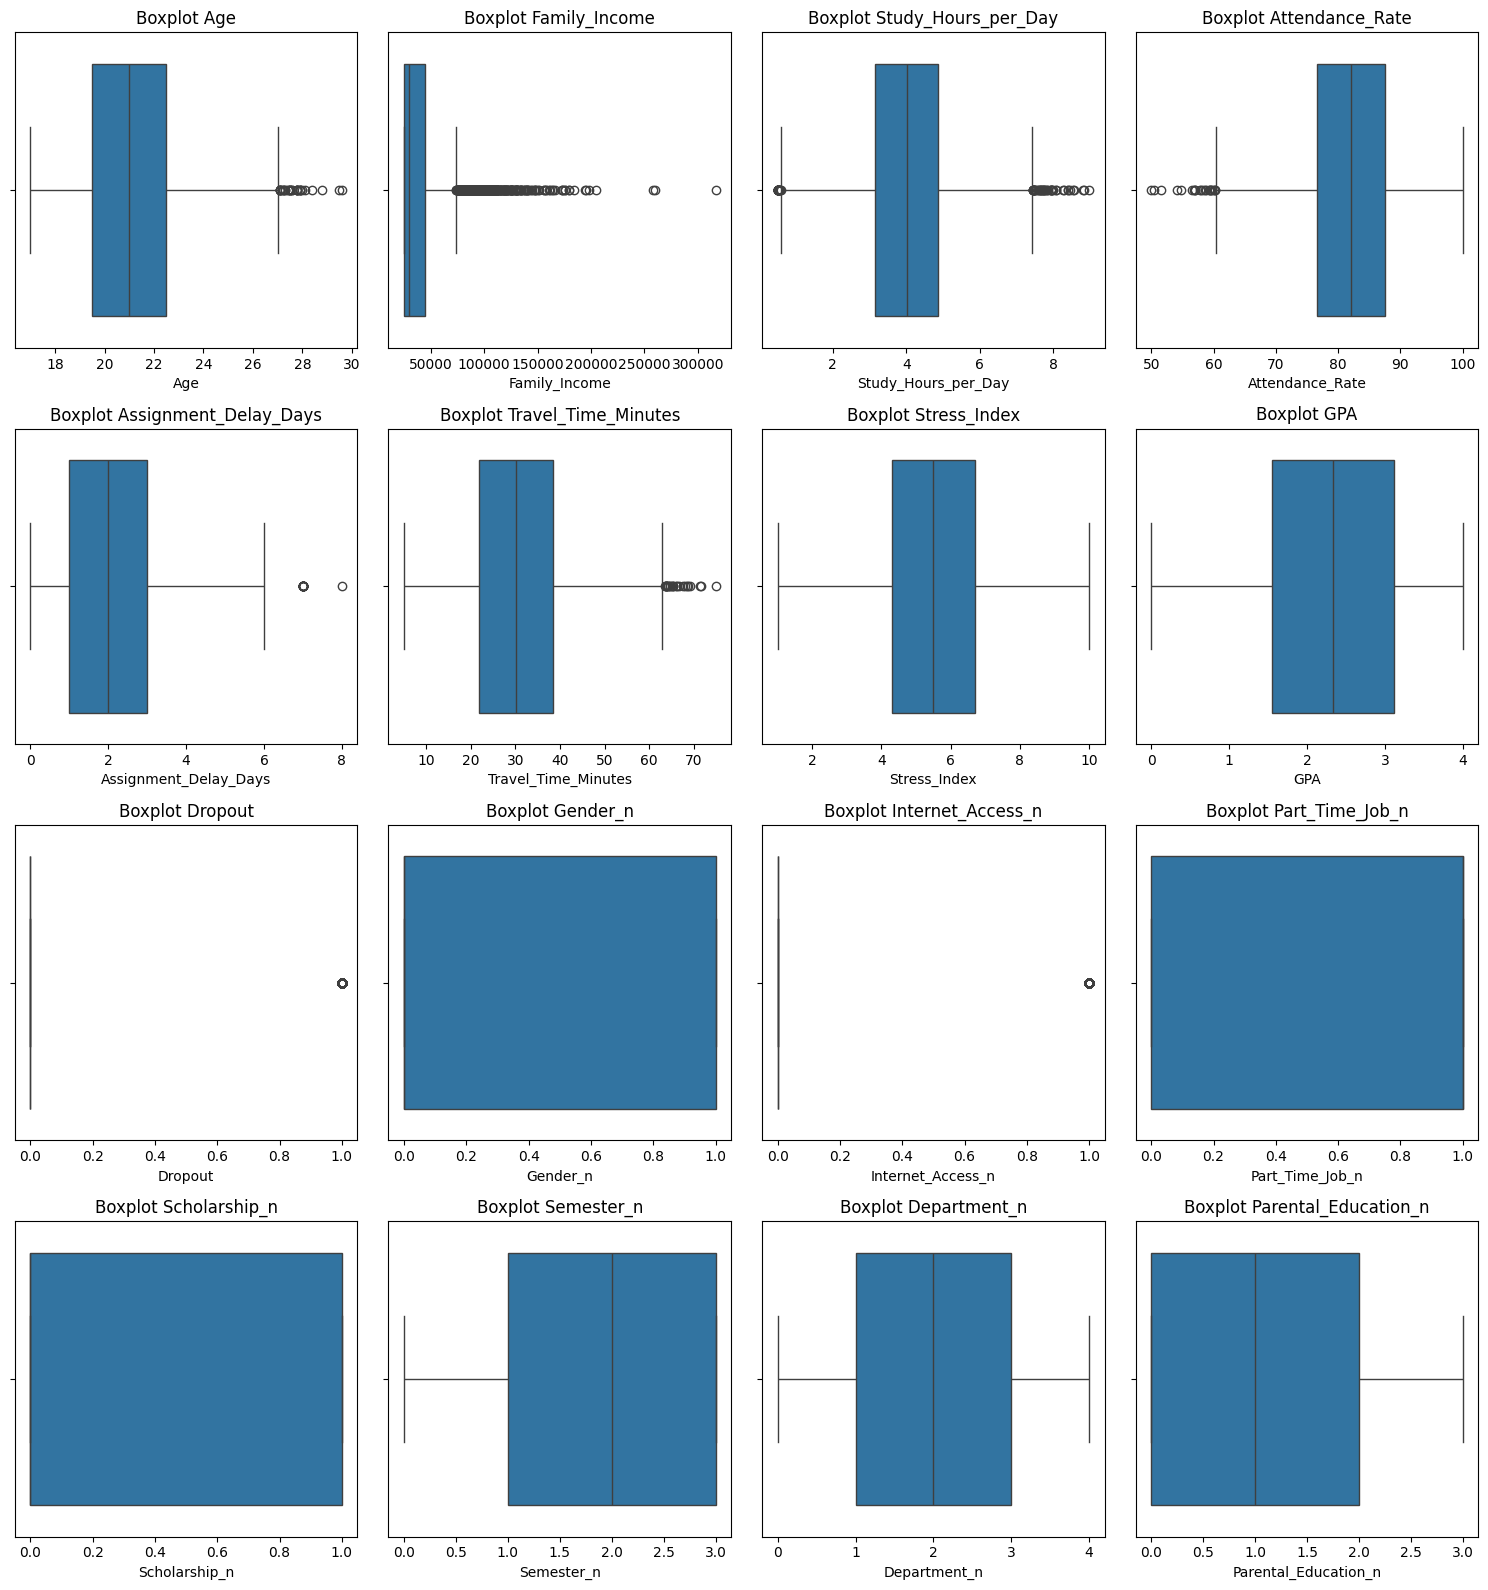

In [15]:
n_cols = 4
n_rows = math.ceil(len(variables) / n_cols)

fig, axis = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axis = axis.flatten()

for i, col in enumerate(variables):
    sns.boxplot(data=total_data, x=col, ax=axis[i])
    axis[i].set_title(f"Boxplot {col}")

plt.tight_layout()
plt.show()

In [16]:
predictoras=[col for col in variables if col != target]
total_data_CON_outliers = total_data.copy()
total_data_SIN_outliers = total_data.copy() # Lo vamos a modificar. Para cada variable con outliers, reemplazamos sus valores outliers

outliers_cols = predictoras

def replace_outliers(column, df):
  col_stats = total_data[column].describe()
  col_iqr = col_stats["75%"] - col_stats["25%"]
  upper_limit = round(float(col_stats["75%"] + 1.5 * col_iqr), 2)
  lower_limit = round(float(col_stats["25%"] - 1.5 * col_iqr), 2)

  if lower_limit < 0: lower_limit = min(df[column])
  # Vamos a quitar los outliers superiores
  df[column] = df[column].apply(lambda x: x if (x <= upper_limit) else upper_limit)
  # Vamos a quitar los outliers inferiores
  df[column] = df[column].apply(lambda x: x if (x >= lower_limit) else lower_limit)
  return df.copy(), [lower_limit, upper_limit]

outliers_dict = {}
for column in outliers_cols:
  total_data_SIN_outliers, limits = replace_outliers(column, total_data_SIN_outliers)
  outliers_dict.update({column: limits})

outliers_dict # Este JSON me lo tengo que GUARDAR
with open("./outliers_dict.json", "w") as f:
  json.dump(outliers_dict, f)

In [17]:
total_data_CON_outliers.isnull().sum().sort_values(ascending=False)


Age                      0
Family_Income            0
Study_Hours_per_Day      0
Attendance_Rate          0
Assignment_Delay_Days    0
Travel_Time_Minutes      0
Stress_Index             0
GPA                      0
Dropout                  0
Gender_n                 0
Internet_Access_n        0
Part_Time_Job_n          0
Scholarship_n            0
Semester_n               0
Department_n             0
Parental_Education_n     0
dtype: int64

In [18]:
total_data_SIN_outliers.isnull().sum().sort_values(ascending=False)

Age                      0
Family_Income            0
Study_Hours_per_Day      0
Attendance_Rate          0
Assignment_Delay_Days    0
Travel_Time_Minutes      0
Stress_Index             0
GPA                      0
Dropout                  0
Gender_n                 0
Internet_Access_n        0
Part_Time_Job_n          0
Scholarship_n            0
Semester_n               0
Department_n             0
Parental_Education_n     0
dtype: int64

In [19]:
# total_data_SIN_outliers
# total_data_CON_outliers
X_CON = total_data_CON_outliers.drop(target, axis = 1)[predictoras]
X_SIN = total_data_SIN_outliers.drop(target, axis = 1)[predictoras]
y = total_data_CON_outliers[target]

X_train_CON_outliers, X_test_CON_outliers, y_train, y_test = train_test_split(X_CON, y, test_size = 0.2, random_state = 10)
X_train_SIN_outliers, X_test_SIN_outliers = train_test_split(X_SIN, test_size = 0.2, random_state = 10)

In [20]:
# X_train_CON_outliers
# X_train_SIN_outliers

# X_test_CON_outliers
# X_test_SIN_outliers

# TENGO QUE GUARDARME TRES SITUACIONES: 1) DATASET SIN TOCAR, 2) DATASET NORMALIZADO, 3) DATASET MIN-MAX

## NORMALIZACIÓN
### CON OUTLIERS
norm_CON_outliers = StandardScaler()
norm_CON_outliers.fit(X_train_CON_outliers)

X_train_CON_outliers_norm = norm_CON_outliers.transform(X_train_CON_outliers)
X_train_CON_outliers_norm = pd.DataFrame(X_train_CON_outliers_norm, index = X_train_CON_outliers.index, columns = predictoras)

X_test_CON_outliers_norm = norm_CON_outliers.transform(X_test_CON_outliers)
X_test_CON_outliers_norm = pd.DataFrame(X_test_CON_outliers_norm, index = X_test_CON_outliers.index, columns = predictoras)

### SIN OUTLIERS
norm_SIN_outliers = StandardScaler()
norm_SIN_outliers.fit(X_train_SIN_outliers)

X_train_SIN_outliers_norm = norm_SIN_outliers.transform(X_train_SIN_outliers)
X_train_SIN_outliers_norm = pd.DataFrame(X_train_SIN_outliers_norm, index = X_train_SIN_outliers.index, columns = predictoras)

X_test_SIN_outliers_norm = norm_SIN_outliers.transform(X_test_SIN_outliers)
X_test_SIN_outliers_norm = pd.DataFrame(X_test_SIN_outliers_norm, index = X_test_SIN_outliers.index, columns = predictoras)


## ESCALADO MIN-MAX (MINMAXIMIZACIÓN)
### CON OUTLIERS
scaler_CON_outliers = MinMaxScaler()
scaler_CON_outliers.fit(X_train_CON_outliers)

X_train_CON_outliers_scal = scaler_CON_outliers.transform(X_train_CON_outliers)
X_train_CON_outliers_scal = pd.DataFrame(X_train_CON_outliers_scal, index = X_train_CON_outliers.index, columns = predictoras)

X_test_CON_outliers_scal = scaler_CON_outliers.transform(X_test_CON_outliers)
X_test_CON_outliers_scal = pd.DataFrame(X_test_CON_outliers_scal, index = X_test_CON_outliers.index, columns = predictoras)

### SIN OUTLIERS
scaler_SIN_outliers = MinMaxScaler()
scaler_SIN_outliers.fit(X_train_SIN_outliers)

X_train_SIN_outliers_scal = scaler_SIN_outliers.transform(X_train_SIN_outliers)
X_train_SIN_outliers_scal = pd.DataFrame(X_train_SIN_outliers_scal, index = X_train_SIN_outliers.index, columns = predictoras)

X_test_SIN_outliers_scal = scaler_SIN_outliers.transform(X_test_SIN_outliers)
X_test_SIN_outliers_scal = pd.DataFrame(X_test_SIN_outliers_scal, index = X_test_SIN_outliers.index, columns = predictoras)

# X_train_CON_outliers
# X_train_CON_outliers_norm
# X_train_CON_outliers_scal
# X_train_SIN_outliers
# X_train_SIN_outliers_norm
# X_train_SIN_outliers_scal

# X_test_CON_outliers
# X_test_CON_outliers_norm
# X_test_CON_outliers_scal
# X_test_SIN_outliers
# X_test_SIN_outliers_norm
# X_test_SIN_outliers_scal

In [21]:
X_train_CON_outliers.to_excel("/workspaces/machine-learning-python-template10-JohnnyXavierReyesBorbor/data/processed/X_train_CON_outliers.xlsx", index = False)
X_train_CON_outliers_norm.to_excel("/workspaces/machine-learning-python-template10-JohnnyXavierReyesBorbor/data/processed/X_train_CON_outliers_norm.xlsx", index = False)
X_train_CON_outliers_scal.to_excel("/workspaces/machine-learning-python-template10-JohnnyXavierReyesBorbor/data/processed/X_train_CON_outliers_scal.xlsx", index = False)
X_train_SIN_outliers.to_excel("/workspaces/machine-learning-python-template10-JohnnyXavierReyesBorbor/data/processed/X_train_SIN_outliers.xlsx", index = False)
X_train_SIN_outliers_norm.to_excel("/workspaces/machine-learning-python-template10-JohnnyXavierReyesBorbor/data/processed/X_train_SIN_outliers_norm.xlsx", index = False)
X_train_SIN_outliers_scal.to_excel("/workspaces/machine-learning-python-template10-JohnnyXavierReyesBorbor/data/processed/X_train_SIN_outliers_scal.xlsx", index = False)

X_test_CON_outliers.to_excel("/workspaces/machine-learning-python-template10-JohnnyXavierReyesBorbor/data/processed/X_test_CON_outliers.xlsx", index = False)
X_test_CON_outliers_norm.to_excel("/workspaces/machine-learning-python-template10-JohnnyXavierReyesBorbor/data/processed/X_test_CON_outliers_norm.xlsx", index = False)
X_test_CON_outliers_scal.to_excel("/workspaces/machine-learning-python-template10-JohnnyXavierReyesBorbor/data/processed/X_test_CON_outliers_scal.xlsx", index = False)
X_test_SIN_outliers.to_excel("/workspaces/machine-learning-python-template10-JohnnyXavierReyesBorbor/data/processed/X_test_SIN_outliers.xlsx", index = False)
X_test_SIN_outliers_norm.to_excel("/workspaces/machine-learning-python-template10-JohnnyXavierReyesBorbor/data/processed/X_test_SIN_outliers_norm.xlsx", index = False)
X_test_SIN_outliers_scal.to_excel("/workspaces/machine-learning-python-template10-JohnnyXavierReyesBorbor/data/processed/X_test_SIN_outliers_scal.xlsx", index = False)

y_train.to_excel("/workspaces/machine-learning-python-template10-JohnnyXavierReyesBorbor/data/processed/y_train.xlsx", index = False)
y_test.to_excel("/workspaces/machine-learning-python-template10-JohnnyXavierReyesBorbor/data/processed/y_test.xlsx", index = False)

# SCALERS


with open("/workspaces/machine-learning-python-template10-JohnnyXavierReyesBorbor/models/norm_CON_outliers.pkl", "wb") as file:
  pickle.dump(norm_CON_outliers, file)
with open("/workspaces/machine-learning-python-template10-JohnnyXavierReyesBorbor/models/norm_SIN_outliers.pkl", "wb") as file:
  pickle.dump(norm_SIN_outliers, file)
with open("/workspaces/machine-learning-python-template10-JohnnyXavierReyesBorbor/models/scaler_CON_outliers.pkl", "wb") as file:
  pickle.dump(scaler_CON_outliers, file)
with open("/workspaces/machine-learning-python-template10-JohnnyXavierReyesBorbor/models/scaler_SIN_outliers.pkl", "wb") as file:
  pickle.dump(scaler_SIN_outliers, file)

In [22]:
datasets = [
    X_train_CON_outliers,
    X_train_CON_outliers_norm,
    X_train_CON_outliers_scal,
    X_train_SIN_outliers,
    X_train_SIN_outliers_norm,
    X_train_SIN_outliers_scal
]
dataset_names = [
    "X_train_CON_outliers",
    "X_train_CON_outliers_norm",
    "X_train_CON_outliers_scal",
    "X_train_SIN_outliers",
    "X_train_SIN_outliers_norm",
    "X_train_SIN_outliers_scal"]

models = []
accs = []
for i,dataset in enumerate(datasets):
  model = LogisticRegression(random_state=10) # Regresión Logística
  model.fit(dataset, y_train) # Entreno el modelo
  y_pred = model.predict(dataset)
  acc = accuracy_score(y_train, y_pred)
  accs.append(acc)
  models.append(model)
  print(f"Accuracy del dataset {i}: {acc:.4f}")

best_acc = max(accs)
best_index = accs.index(best_acc)
print(f"\nEl mejor dataset es el dataset {best_index}, es decir, {dataset_names[best_index]} con accuracy = {best_acc:.4f}")

Accuracy del dataset 0: 0.8022
Accuracy del dataset 1: 0.8139
Accuracy del dataset 2: 0.8135
Accuracy del dataset 3: 0.8024
Accuracy del dataset 4: 0.8122
Accuracy del dataset 5: 0.8136

El mejor dataset es el dataset 1, es decir, X_train_CON_outliers_norm con accuracy = 0.8139


In [23]:
params = {
    "C": [0.001, 0.01, 0.1, 1, 10, 100, 1000],
    "penalty": ["l1", "l2", "elasticnet", None],
    "solver": ["newton-cg", "lbfgs", "liblinear", "sag", "saga"]
}


grid = GridSearchCV(LogisticRegression(random_state=10), params, scoring = "accuracy")
grid.fit(datasets[best_index], y_train) # Entreno el optimizador con el dataset GANADOR
print(grid.best_params_)
best_model = grid.best_estimator_

{'C': 0.001, 'penalty': None, 'solver': 'newton-cg'}


In [24]:
model_grid = LogisticRegression(penalty = None , C = 0.001, solver = "newton-cg")
model_grid.fit(datasets[best_index], y_train)
y_pred = model_grid.predict(X_test_CON_outliers_norm)

grid_accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy anterior: {best_acc}")
print(f"Accuracy optimizado: {grid_accuracy}")

Accuracy anterior: 0.8138858093126385
Accuracy optimizado: 0.8087583148558758


## **Paso 3: Desarrolla una aplicación web usando Flask**

In [25]:
import joblib

joblib.dump(model, "../models/model.pkl")

['../models/model.pkl']